In [1]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import time

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense, Dropout
from tensorflow.keras.models import Model

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    accuracy_score
)

In [2]:
dataset_path = r"D:\AIML Assignments\Week-1\Question-9\Face Mask Dataset"

In [3]:
datagen = ImageDataGenerator(
    rescale=1./255,
    validation_split=0.20,
    rotation_range=20,
    zoom_range=0.20,
    horizontal_flip=True
)

In [4]:
train_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="training"
)

Found 6043 images belonging to 2 classes.


In [5]:
validation_generator = datagen.flow_from_directory(
    dataset_path,
    target_size=(224,224),
    batch_size=32,
    class_mode="binary",
    subset="validation",
    shuffle=False
)

Found 1510 images belonging to 2 classes.


In [6]:
print(train_generator.class_indices)

{'with_mask': 0, 'without_mask': 1}


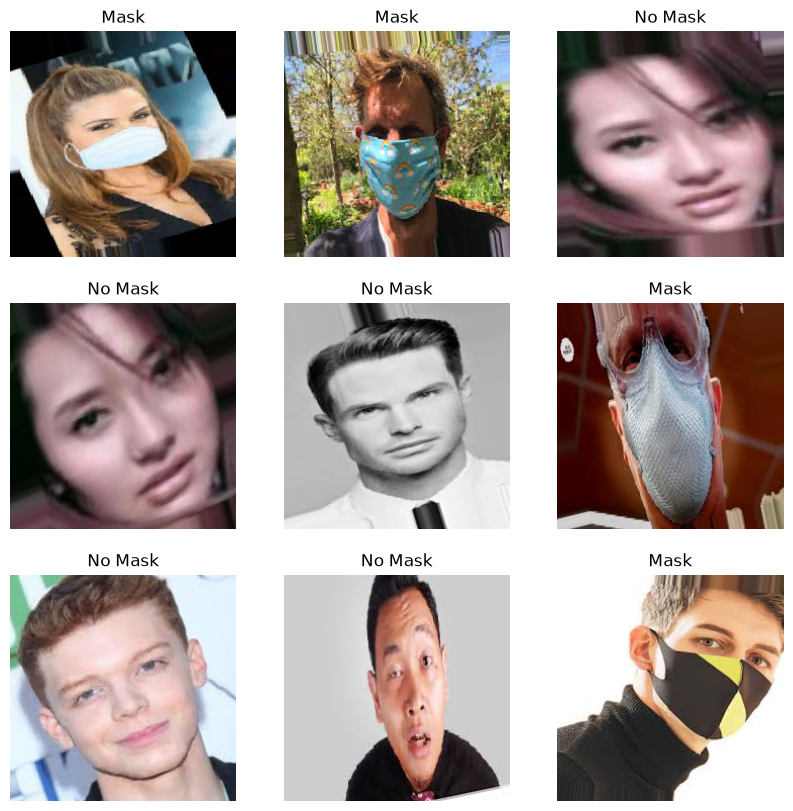

In [7]:
images, labels = next(train_generator)

plt.figure(figsize=(10,10))

for i in range(9):
    plt.subplot(3,3,i+1)
    plt.imshow(images[i])
    plt.title("Mask" if labels[i]==0 else "No Mask")
    plt.axis("off")

plt.show()

In [8]:
base_model = MobileNetV2(
    weights="imagenet",
    include_top=False,
    input_shape=(224,224,3)
)

In [9]:
for layer in base_model.layers:
    layer.trainable = False

In [10]:
x = base_model.output

x = GlobalAveragePooling2D()(x)

x = Dense(128, activation="relu")(x)

x = Dropout(0.3)(x)

output = Dense(1, activation="sigmoid")(x)

model = Model(inputs=base_model.input, outputs=output)

In [11]:
model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy"]
)

In [12]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                  ┃ Output Shape              ┃         Param # ┃ Connected to               ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)      │ (None, 224, 224, 3)       │               0 │ -                          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1 (Conv2D)                │ (None, 112, 112, 32)      │             864 │ input_layer[0][0]          │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ bn_Conv1 (BatchNormalization) │ (None, 112, 112, 32)      │             128 │ Conv1[0][0]                │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ Conv1_relu (ReLU)             │ (None, 112, 112, 32)      │               0 │ bn_Conv1[0][0]             │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise       │ (None, 112, 112, 32)      │             288 │ Conv1_relu[0][0]           │
│ (DepthwiseConv2D)             │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_BN    │ (None, 112, 112, 32)      │             128 │ expanded_conv_depthwise[0… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_depthwise_relu  │ (None, 112, 112, 32)      │               0 │ expanded_conv_depthwise_B… │
│ (ReLU)                        │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project         │ (None, 112, 112, 16)      │             512 │ expanded_conv_depthwise_r… │
│ (Conv2D)                      │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ expanded_conv_project_BN      │ (None, 112, 112, 16)      │              64 │ expanded_conv_project[0][… │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand (Conv2D)       │ (None, 112, 112, 96)      │           1,536 │ expanded_conv_project_BN[… │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_BN             │ (None, 112, 112, 96)      │             384 │ block_1_expand[0][0]       │
│ (BatchNormalization)          │                           │                 │                            │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_expand_relu (ReLU)    │ (None, 112, 112, 96)      │               0 │ block_1_expand_BN[0][0]    │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_pad (ZeroPadding2D)   │ (None, 113, 113, 96)      │               0 │ block_1_expand_relu[0][0]  │
├───────────────────────────────┼───────────────────────────┼─────────────────┼────────────────────────────┤
│ block_1_depthwise             │ (None, 56, 56, 96)        │             864 │ block_1_pad[0][0]          │
│ (DepthwiseConv2D)             │                           │               

 Total params: 2,422,081 (9.24 MB)

 Trainable params: 164,097 (641.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [13]:
history = model.fit(
    train_generator,
    validation_data=validation_generator,
    epochs=10
)

Epoch 1/10
 14/189 ━━━━━━━━━━━━━━━━━━━━ 3:57 1s/step - accuracy: 0.9062 - loss: 0.2322

D:\Anaconda\envs\opencv-env\Lib\site-packages\PIL\Image.py:1045: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


189/189 ━━━━━━━━━━━━━━━━━━━━ 360s 2s/step - accuracy: 0.9702 - loss: 0.0802 - val_accuracy: 0.9868 - val_loss: 0.0410
Epoch 2/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 355s 2s/step - accuracy: 0.9823 - loss: 0.0489 - val_accuracy: 0.9881 - val_loss: 0.0383
Epoch 3/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 334s 2s/step - accuracy: 0.9874 - loss: 0.0335 - val_accuracy: 0.9828 - val_loss: 0.0527
Epoch 4/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 412s 2s/step - accuracy: 0.9883 - loss: 0.0304 - val_accuracy: 0.9841 - val_loss: 0.0464
Epoch 5/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 333s 2s/step - accuracy: 0.9916 - loss: 0.0246 - val_accuracy: 0.9914 - val_loss: 0.0454
Epoch 6/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 1200s 6s/step - accuracy: 0.9921 - loss: 0.0204 - val_accuracy: 0.9828 - val_loss: 0.0508
Epoch 7/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 556s 3s/step - accuracy: 0.9911 - loss: 0.0215 - val_accuracy: 0.9848 - val_loss: 0.0553
Epoch 8/10
189/189 ━━━━━━━━━━━━━━━━━━━━ 314s 2s/step - accuracy: 0.9911 - loss: 0.0222 - val_accuracy: 0.99

In [14]:
loss, accuracy = model.evaluate(validation_generator)

print("Validation Loss :", loss)
print("Validation Accuracy :", accuracy)

48/48 ━━━━━━━━━━━━━━━━━━━━ 232s 5s/step - accuracy: 0.9914 - loss: 0.0271
Validation Loss : 0.02710006572306156
Validation Accuracy : 0.9913907051086426


In [17]:
predictions = model.predict(validation_generator)

predictions = (predictions > 0.5).astype(int)

true_labels = validation_generator.classes

48/48 ━━━━━━━━━━━━━━━━━━━━ 5111s 109s/step


In [18]:
acc = accuracy_score(true_labels, predictions)

print("Accuracy :", acc)

Accuracy : 0.9920529801324504


In [19]:
precision = precision_score(true_labels, predictions)

print("Precision :", precision)

Precision : 0.9921568627450981


In [20]:
recall = recall_score(true_labels, predictions)

print("Recall :", recall)

Recall : 0.9921568627450981


In [21]:
print(classification_report(true_labels, predictions))

              precision    recall  f1-score   support

           0       0.99      0.99      0.99       745
           1       0.99      0.99      0.99       765

    accuracy                           0.99      1510
   macro avg       0.99      0.99      0.99      1510
weighted avg       0.99      0.99      0.99      1510



In [22]:
cm = confusion_matrix(true_labels, predictions)

print(cm)

[[739   6]
 [  6 759]]


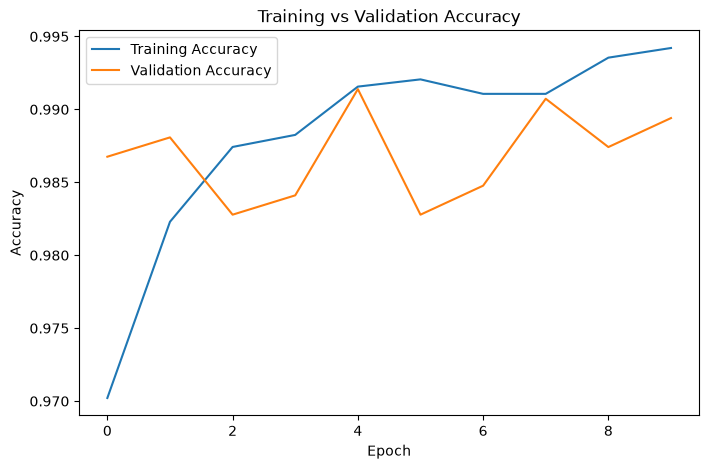

In [23]:
plt.figure(figsize=(8,5))

plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")
plt.legend()

plt.show()

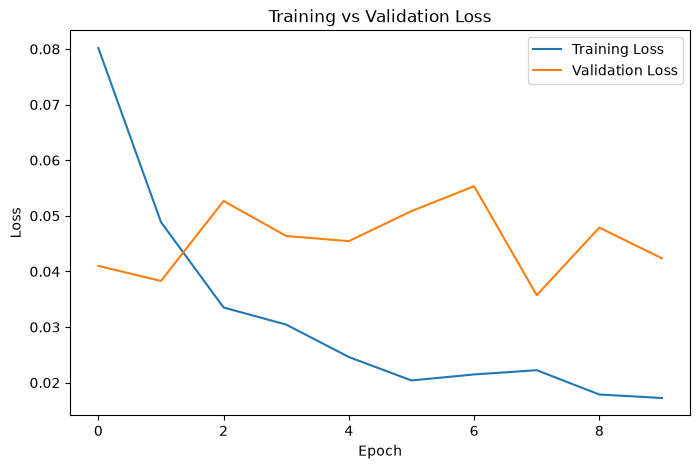

In [24]:
plt.figure(figsize=(8,5))

plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()

plt.show()

In [25]:
sample_image = next(validation_generator)[0][0]

sample_image = np.expand_dims(sample_image, axis=0)

start = time.time()

model.predict(sample_image)

end = time.time()

print("Inference Time :", end-start, "seconds")

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Inference Time : 3.043973445892334 seconds


In [26]:
model.save("FaceMaskMobileNet.keras")

print("Model Saved Successfully!")

Model Saved Successfully!


In [27]:
print("----------- Final Evaluation -----------")
print("Accuracy :", acc)
print("Precision :", precision)
print("Recall :", recall)

----------- Final Evaluation -----------
Accuracy : 0.9920529801324504
Precision : 0.9921568627450981
Recall : 0.9921568627450981
